# Hướng dẫn cài đặt thư mục và chạy notebook trên GPU L4 22.5GB

Notebook này cài đặt **Transformer Base 2017 encoder-decoder from scratch** cho bài toán tóm tắt văn bản tiếng Việt.  
Notebook **không dùng `nn.Transformer`**, không dùng mô hình pretrained để huấn luyện/generate; toàn bộ embedding, positional encoding, multi-head attention, encoder, decoder, feed-forward, residual connection và learning-rate schedule được cài đặt thủ công bằng PyTorch.

## 3 cải tiến mới trong bản này

Bản notebook này giữ kiến trúc lõi **Transformer 2017** nhưng cải tiến pipeline để tối ưu hơn cho dataset tóm tắt tiếng Việt:

1. **SentencePiece BPE tokenizer**
   - Thay tokenizer regex bằng tokenizer BPE train trực tiếp từ `train.parquet`.
   - Giúp xử lý tiếng Việt tốt hơn, giảm `<unk>`, xử lý tên riêng/từ hiếm tốt hơn.
   - Vocabulary chỉ học từ tập train, không học từ validation/test để tránh data leakage.

2. **Dynamic padding + length-bucketed batches**
   - Không padding mọi mẫu lên cùng độ dài cực đại trong `Dataset`.
   - Mỗi batch chỉ padding đến độ dài lớn nhất trong batch.
   - Batch sampler gom các mẫu có độ dài gần nhau để giảm padding thừa, tiết kiệm VRAM trên GPU L4.

3. **Beam search decoding có length penalty và no-repeat n-gram**
   - Thay greedy decoding bằng beam search khi sinh summary để đánh giá validation/test.
   - Thêm `length_penalty` để tránh summary quá ngắn.
   - Thêm `no_repeat_ngram_size` để hạn chế lặp cụm từ.

## Cấu trúc thư mục khuyến nghị

```text
/content/transformer_2017_vi_summarization/
├── data/
│   ├── train.parquet
│   ├── val.parquet
│   └── test.parquet          # chỉ cần thêm khi thầy cung cấp tập test cuối kỳ
└── outputs/
    ├── sentencepiece_bpe_vi.model
    ├── sentencepiece_bpe_vi.vocab
    ├── training_history.csv
    ├── loss_curve.png
    ├── val_predictions.csv
    ├── val_metrics.json
    └── checkpoints/
        ├── transformer_2017_improved_best.pt
        └── transformer_2017_improved_last.pt
```

## Cách chạy

1. Bật GPU L4 trong Colab/Kaggle.
2. Upload `train.parquet` và `val.parquet` vào thư mục `data/`.
3. Chạy `Runtime → Restart session and run all`.
4. Khi thầy cung cấp `test.parquet`, đặt file vào `data/`, đổi `RUN_TEST_EVALUATION = True`, rồi chạy phần test ở cuối notebook.

## Lưu ý quan trọng

Do bản này đổi tokenizer sang SentencePiece nên **checkpoint từ bản regex cũ không tương thích**.  
Bạn cần train lại từ đầu để tạo checkpoint mới `transformer_2017_improved_best.pt`.

# Transformer 2017 from scratch cải tiến cho tóm tắt tiếng Việt

Mục tiêu của notebook:

- Cài đặt đúng kiến trúc **Transformer Base 2017** theo paper *Attention Is All You Need*.
- Giữ kiến trúc lõi nguyên bản: post-norm, sinusoidal positional encoding, multi-head attention chuẩn, FFN ReLU.
- Tối ưu pipeline cho dataset tiếng Việt bằng SentencePiece, dynamic padding/bucketing và beam search decoding.
- Huấn luyện trên `train.parquet`, đánh giá trên `val.parquet`, và chuẩn bị sẵn code cho `test.parquet` cuối kỳ.

# 0. Import thư viện, cố định seed và thiết lập thiết bị

Cell này import thư viện cần thiết, cố định random seed và chọn thiết bị chạy.

Nếu có GPU L4 hoặc GPU NVIDIA hiện đại, notebook bật thêm:

- **TF32** để tăng tốc phép nhân ma trận trên GPU hỗ trợ Tensor Cores;
- **BF16 autocast** nếu GPU/PyTorch hỗ trợ, giúp giảm bộ nhớ khi train.

Các tối ưu BF16/TF32 chỉ thay đổi cách tính toán số học trên GPU, không thay đổi cấu trúc Transformer 2017.


In [1]:
import math
import os
import random
import time
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Tối ưu cho GPU NVIDIA hiện đại như L4/A100.
# TF32 tăng tốc matmul/convolution nhưng vẫn giữ mô hình và công thức Transformer không đổi.
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f'Torch: {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU memory: {total_mem_gb:.2f} GB')


Torch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA L4
GPU memory: 22.03 GB


# 1. Các khối nền tảng của Transformer 2017

Cell này khai báo các thành phần dùng chung trong mô hình:

- `InputEmbedding`: ánh xạ token ID thành embedding và nhân với `sqrt(d_model)`.
- `PositionalEncoding`: sinusoidal positional encoding cố định như paper 2017.
- `LayerNormalization`: tự cài LayerNorm với tham số học được theo từng chiều `d_model`.
- `ResidualConnection`: Add & Norm **post-norm** đúng công thức Transformer 2017:

```python
LayerNorm(x + Dropout(Sublayer(x)))
```

- `create_src_mask`: che padding ở encoder.
- `create_tgt_mask`: che padding và token tương lai ở decoder.


In [2]:
class InputEmbedding(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        # Paper 2017 scale embedding bằng sqrt(d_model) trước khi cộng positional encoding.
        return self.embedding(x) * math.sqrt(self.d_model)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int, dropout: float):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)

        # Positional encoding là hằng số, không phải tham số học được.
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :].requires_grad_(False)
        return self.dropout(x)


class LayerNormalization(nn.Module):
    def __init__(self, features: int, epsilon: float = 1e-6) -> None:
        super().__init__()
        self.epsilon = epsilon
        self.alpha = nn.Parameter(torch.ones(features))
        self.bias = nn.Parameter(torch.zeros(features))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.alpha * (x - mean) / torch.sqrt(var + self.epsilon) + self.bias


class ResidualConnection(nn.Module):
    def __init__(self, d_model: int, dropout: float) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.norm = LayerNormalization(d_model)

    def forward(self, x, sublayer):
        # Transformer 2017 dùng post-norm:
        # LayerNorm(x + Dropout(Sublayer(x)))
        return self.norm(x + self.dropout(sublayer(x)))


def causal_mask(size: int) -> torch.Tensor:
    # True ở các vị trí được phép attention, False ở token tương lai.
    mask = torch.triu(torch.ones(1, size, size, dtype=torch.bool), diagonal=1)
    return ~mask


def create_src_mask(src: torch.Tensor, pad_idx: int = 0) -> torch.Tensor:
    # shape: (batch, 1, 1, src_len), broadcast được sang attention score.
    return (src != pad_idx).unsqueeze(1).unsqueeze(2)


def create_tgt_mask(tgt: torch.Tensor, pad_idx: int = 0) -> torch.Tensor:
    # Padding mask: decoder không attention vào <pad>.
    tgt_pad_mask = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)
    # Causal mask: decoder không nhìn thấy các token tương lai.
    tgt_causal_mask = causal_mask(tgt.size(1)).type_as(tgt_pad_mask).to(tgt.device)
    return tgt_pad_mask & tgt_causal_mask


def create_masks(src: torch.Tensor, tgt: torch.Tensor, pad_idx: int = 0):
    return create_src_mask(src, pad_idx), create_tgt_mask(tgt, pad_idx)


def subsequent_mask(size: int) -> torch.Tensor:
    return causal_mask(size)


# 2. Feed Forward, Multi-Head Attention và Encoder

Cell này cài đặt các thành phần chính của encoder theo Transformer 2017:

- `FeedForwardBlock`: position-wise feed-forward network `Linear → ReLU → Dropout → Linear`.
- `MultiHeadAttentionBlock`: scaled dot-product multi-head attention chuẩn.
- `EncoderBlock`: gồm self-attention và feed-forward, mỗi sub-layer được bọc bằng Add & Norm post-norm.
- `Encoder`: xếp chồng `N` encoder blocks.

Không dùng các biến thể hiện đại như SwiGLU, RMSNorm, RoPE, GQA/MQA hoặc FlashAttention API.


In [3]:
class FeedForwardBlock(nn.Module):
    """Position-wise Feed Forward chuẩn Transformer 2017.

    Công thức: max(0, xW1 + b1)W2 + b2
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(torch.relu(self.linear1(x))))


class MultiHeadAttentionBlock(nn.Module):
    """Multi-Head Attention tiêu chuẩn, không dùng GQA/MQA."""
    def __init__(self, d_model: int, num_head: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model
        self.num_head = num_head
        assert d_model % num_head == 0, 'd_model must be divisible by num_head'

        self.d_k = d_model // num_head
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.attention_score = None

    @staticmethod
    def attention(query, key, value, mask, dropout: nn.Dropout):
        d_k = query.shape[-1]
        attention_score = (query @ key.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            attention_score = attention_score.masked_fill(mask == 0, -1e9)

        attention_score = attention_score.softmax(dim=-1)

        if dropout is not None:
            attention_score = dropout(attention_score)

        return attention_score @ value, attention_score

    def forward(self, q, k, v, mask):
        query = self.w_q(q)
        key = self.w_k(k)
        value = self.w_v(v)

        batch_size = query.shape[0]
        query = query.view(batch_size, -1, self.num_head, self.d_k).transpose(1, 2)
        key = key.view(batch_size, -1, self.num_head, self.d_k).transpose(1, 2)
        value = value.view(batch_size, -1, self.num_head, self.d_k).transpose(1, 2)

        x, self.attention_score = MultiHeadAttentionBlock.attention(
            query, key, value, mask, self.dropout
        )

        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.num_head * self.d_k)
        return self.w_o(x)


class EncoderBlock(nn.Module):
    def __init__(self, self_attention_block: MultiHeadAttentionBlock, feed_forward_block: FeedForwardBlock, d_model: int, dropout: float) -> None:
        super().__init__()
        self.self_attention_block = self_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connection = nn.ModuleList([
            ResidualConnection(d_model, dropout) for _ in range(2)
        ])

    def forward(self, x, src_mask):
        x = self.residual_connection[0](x, lambda x: self.self_attention_block(x, x, x, src_mask))
        x = self.residual_connection[1](x, self.feed_forward_block)
        return x


class Encoder(nn.Module):
    def __init__(self, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers

    def forward(self, x, mask):
        # Transformer 2017 không cần final LayerNorm ngoài stack,
        # vì mỗi sub-layer đã có Add & Norm dạng post-norm.
        for layer in self.layers:
            x = layer(x, mask)
        return x


# 3. Decoder, projection layer và hàm build Transformer

Cell này cài đặt decoder và hàm đóng gói mô hình:

- `DecoderBlock`: gồm masked self-attention, cross-attention và feed-forward.
- `Decoder`: xếp chồng `N` decoder blocks.
- `ProjectionLayer`: chiếu hidden state của decoder sang vocabulary và trả **logits thô**.
- `Transformer`: gom encoder, decoder, embedding, positional encoding và projection.
- `build_transformer`: khởi tạo Transformer Base theo cấu hình 2017.

Vì projection trả logits thô, training sử dụng `nn.CrossEntropyLoss`. Cách này tương đương linear + softmax khi tính loss, đúng với mô tả của paper.


In [4]:
class DecoderBlock(nn.Module):
    def __init__(self, self_attention: MultiHeadAttentionBlock, cross_attention: MultiHeadAttentionBlock, feed_forward_block: FeedForwardBlock, d_model: int, dropout: float) -> None:
        super().__init__()
        self.self_attention = self_attention
        self.cross_attention = cross_attention
        self.feed_forward_block = feed_forward_block
        self.residual_connection = nn.ModuleList([
            ResidualConnection(d_model, dropout) for _ in range(3)
        ])

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        x = self.residual_connection[0](x, lambda x: self.self_attention(x, x, x, tgt_mask))
        x = self.residual_connection[1](x, lambda x: self.cross_attention(x, encoder_output, encoder_output, src_mask))
        x = self.residual_connection[2](x, self.feed_forward_block)
        return x


class Decoder(nn.Module):
    def __init__(self, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        # Transformer 2017 không thêm final norm ngoài decoder stack.
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return x


class ProjectionLayer(nn.Module):
    def __init__(self, d_model: int, vocab_size: int) -> None:
        super().__init__()
        self.projection = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # Trả logits thô. CrossEntropyLoss sẽ tự áp dụng log_softmax bên trong.
        return self.projection(x)


class Transformer(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder, src_embed: InputEmbedding, tgt_embed: InputEmbedding, src_pos: PositionalEncoding, tgt_pos: PositionalEncoding, projection_layer: ProjectionLayer) -> None:
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.src_pos = src_pos
        self.tgt_pos = tgt_pos
        self.projection_layer = projection_layer

    def encode(self, src, src_mask):
        src = self.src_embed(src)
        src = self.src_pos(src)
        return self.encoder(src, src_mask)

    def decode(self, encoder_output, src_mask, tgt, tgt_mask):
        tgt = self.tgt_embed(tgt)
        tgt = self.tgt_pos(tgt)
        return self.decoder(tgt, encoder_output, src_mask, tgt_mask)

    def project(self, x):
        return self.projection_layer(x)


def build_transformer(
    src_vocab_size: int,
    tgt_vocab_size: int,
    src_seq_len: int,
    tgt_seq_len: int,
    d_model: int = 512,
    N: int = 6,
    h: int = 8,
    dropout: float = 0.1,
    d_ff: int = 2048,
    share_embeddings: bool = True,
) -> Transformer:
    src_embed = InputEmbedding(d_model, src_vocab_size)
    tgt_embed = InputEmbedding(d_model, tgt_vocab_size)

    src_pos = PositionalEncoding(d_model, src_seq_len, dropout)
    tgt_pos = PositionalEncoding(d_model, tgt_seq_len, dropout)

    encoder_blocks = []
    for _ in range(N):
        encoder_self_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward_block = FeedForwardBlock(d_model, d_ff, dropout)
        encoder_block = EncoderBlock(encoder_self_attention_block, feed_forward_block, d_model, dropout)
        encoder_blocks.append(encoder_block)

    decoder_blocks = []
    for _ in range(N):
        decoder_self_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        decoder_cross_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward_block = FeedForwardBlock(d_model, d_ff, dropout)
        decoder_block = DecoderBlock(decoder_self_attention_block, decoder_cross_attention_block, feed_forward_block, d_model, dropout)
        decoder_blocks.append(decoder_block)

    encoder = Encoder(nn.ModuleList(encoder_blocks))
    decoder = Decoder(nn.ModuleList(decoder_blocks))
    projection_layer = ProjectionLayer(d_model, tgt_vocab_size)

    transformer = Transformer(encoder, decoder, src_embed, tgt_embed, src_pos, tgt_pos, projection_layer)

    # Xavier initialization như các implementation Transformer cổ điển.
    for p in transformer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

    # Paper 2017 chia sẻ embedding và pre-softmax weight khi source/target dùng chung vocabulary.
    # Với bài tóm tắt tiếng Việt, source và target dùng chung vocab nên có thể bật weight tying.
    if share_embeddings and src_vocab_size == tgt_vocab_size:
        transformer.tgt_embed.embedding.weight = transformer.src_embed.embedding.weight
        transformer.projection_layer.projection.weight = transformer.tgt_embed.embedding.weight

    return transformer


# 4. Kiểm tra nhanh forward pass bằng dữ liệu giả

Cell này tạo mô hình nhỏ và batch token ngẫu nhiên để kiểm tra luồng tensor:

- source và target token IDs;
- source mask và target causal mask;
- encoder output;
- decoder output;
- logits sau projection.

Nếu các `assert` pass, mô hình đã chạy đúng về mặt shape. Đây chưa phải training thật.


In [5]:
PAD_IDX = 0
SRC_VOCAB_SIZE = 120
TGT_VOCAB_SIZE = 120
SRC_SEQ_LEN = 12
TGT_SEQ_LEN = 10
BATCH_SIZE = 4

model = build_transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    src_seq_len=SRC_SEQ_LEN,
    tgt_seq_len=TGT_SEQ_LEN,
    d_model=64,
    N=2,
    h=4,
    dropout=0.1,
    d_ff=128,
    share_embeddings=True,
).to(device)

src = torch.randint(1, SRC_VOCAB_SIZE, (BATCH_SIZE, SRC_SEQ_LEN), device=device)
tgt_input = torch.randint(1, TGT_VOCAB_SIZE, (BATCH_SIZE, TGT_SEQ_LEN), device=device)

src[:, -2:] = PAD_IDX
tgt_input[:, -1:] = PAD_IDX

src_mask, tgt_mask = create_masks(src, tgt_input, pad_idx=PAD_IDX)

encoder_output = model.encode(src, src_mask)
decoder_output = model.decode(encoder_output, src_mask, tgt_input, tgt_mask)
logits = model.project(decoder_output)

print('src:', tuple(src.shape))
print('tgt_input:', tuple(tgt_input.shape))
print('src_mask:', tuple(src_mask.shape))
print('tgt_mask:', tuple(tgt_mask.shape))
print('encoder_output:', tuple(encoder_output.shape))
print('decoder_output:', tuple(decoder_output.shape))
print('logits:', tuple(logits.shape))

assert logits.shape == (BATCH_SIZE, TGT_SEQ_LEN, TGT_VOCAB_SIZE)
print('Forward pass OK.')


src: (4, 12)
tgt_input: (4, 10)
src_mask: (4, 1, 1, 12)
tgt_mask: (4, 1, 10, 10)
encoder_output: (4, 12, 64)
decoder_output: (4, 10, 64)
logits: (4, 10, 120)
Forward pass OK.


# 5. Một bước huấn luyện giả lập

Cell này chạy một bước training trên dữ liệu ngẫu nhiên để kiểm tra:

- `CrossEntropyLoss` nhận logits thô;
- padding token được bỏ qua bằng `ignore_index=PAD_IDX`;
- backward pass hoạt động;
- optimizer cập nhật được trọng số.

Đây chỉ là bước kiểm tra kỹ thuật trước khi gắn dataset thật.


In [6]:
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
criterion_dummy = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

target = torch.randint(1, TGT_VOCAB_SIZE, (BATCH_SIZE, TGT_SEQ_LEN), device=device)
target[:, -1:] = PAD_IDX

optimizer.zero_grad(set_to_none=True)

encoder_output = model.encode(src, src_mask)
decoder_output = model.decode(encoder_output, src_mask, tgt_input, tgt_mask)
logits = model.project(decoder_output)

loss = criterion_dummy(logits.reshape(-1, TGT_VOCAB_SIZE), target.reshape(-1))
loss.backward()
optimizer.step()

num_params = sum(p.numel() for p in model.parameters())
print(f'loss: {loss.item():.4f}')
print(f'parameters: {num_params:,}')


loss: 5.1505
parameters: 175,224


# 6. Gắn dataset `article → summary` cho bài toán tóm tắt

Phần này chuyển từ dữ liệu giả sang dataset thật có hai cột:

- `article`: văn bản đầu vào cho encoder;
- `summary`: bản tóm tắt mục tiêu cho decoder.

Pipeline gồm:

1. cài thư viện đọc Parquet;
2. cấu hình thư mục, token đặc biệt, độ dài chuỗi và tham số L4 22.5GB;
3. đọc và làm sạch dataset;
4. tokenize văn bản;
5. build vocabulary;
6. mã hóa `article` và `summary` thành token IDs;
7. tạo `Dataset` và `DataLoader`;
8. train và validate mô hình.


# 6.1. Cài thư viện đọc dữ liệu, tokenizer và đánh giá summarization

In [7]:
%pip install -q pandas pyarrow fastparquet sentencepiece rouge-score bert-score sacrebleu

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 13.9 MB/s eta 0:00:00


# 6.2. Cấu hình thư mục, SentencePiece, Transformer và tham số L4 22.5GB

In [8]:
import re
import random
import sentencepiece as spm

import pandas as pd
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence

# -------------------------
# Thư mục làm việc
# -------------------------
PROJECT_ROOT = Path('/content/transformer_2017_vi_summarization')
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'

for directory in [DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# -------------------------
# Tên file dữ liệu
# -------------------------
TRAIN_FILENAME = 'train.parquet'
VALID_FILENAME = 'val.parquet'

# Tập test chưa có ở giai đoạn train. Đến ngày cuối, chỉ cần đặt file đúng tên này
# vào DATA_DIR và bật RUN_TEST_EVALUATION ở phần cấu hình test bên dưới.
TEST_FILENAME = 'test.parquet'

# Nếu True, notebook bắt buộc phải có val.parquet và sẽ không tự chia validation từ train.
REQUIRE_VALID_FILE = True

# -------------------------
# Token đặc biệt
# -------------------------
# SentencePiece sẽ được train với đúng ID:
# <pad>=0, <unk>=1, <bos>=2, <eos>=3
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'
BOS_TOKEN = '<bos>'
EOS_TOKEN = '<eos>'

PAD_IDX = 0
UNK_IDX = 1
BOS_IDX = 2
EOS_IDX = 3

SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

# -------------------------
# Cải tiến 1: SentencePiece BPE tokenizer
# -------------------------
TOKENIZER_TYPE = 'sentencepiece_bpe'

# Với dataset khoảng vài chục nghìn mẫu, 16k thường ổn hơn 32k:
# - đủ biểu diễn tiếng Việt;
# - giảm số tham số embedding/projection;
# - giảm độ khó dự đoán token khi train from scratch.
SENTENCEPIECE_VOCAB_SIZE = 16_000

# character_coverage cao để giữ dấu tiếng Việt và ký tự Unicode quan trọng.
SENTENCEPIECE_CHARACTER_COVERAGE = 0.9995

# Đặt True nếu muốn train lại tokenizer kể cả khi file .model đã tồn tại.
# Khi đổi VOCAB_SIZE/kiểu tokenizer, nên bật True trong lần chạy đầu.
FORCE_RETRAIN_SENTENCEPIECE = False

SENTENCEPIECE_MODEL_PREFIX = OUTPUT_DIR / 'sentencepiece_bpe_vi'
SENTENCEPIECE_MODEL_PATH = Path(str(SENTENCEPIECE_MODEL_PREFIX) + '.model')
SENTENCEPIECE_VOCAB_PATH = Path(str(SENTENCEPIECE_MODEL_PREFIX) + '.vocab')
SENTENCEPIECE_CORPUS_PATH = OUTPUT_DIR / 'sentencepiece_train_corpus.txt'

# -------------------------
# Cấu hình độ dài chuỗi
# -------------------------
# Đây là độ dài tối đa. Nhờ dynamic padding, mỗi batch chỉ pad đến độ dài dài nhất trong batch.
SRC_SEQ_LEN = 384         # L4 22.5GB: giảm độ dài article để tránh OOM với attention O(n^2).
TGT_SEQ_LEN = 128         # Đủ cho summary tiếng Việt ngắn/trung bình.

# Đặt None để dùng toàn bộ dataset. Đổi thành số nhỏ nếu muốn debug nhanh.
QUICK_TRAIN_SAMPLES = None
QUICK_VALID_SAMPLES = None

# -------------------------
# Cải tiến 2: Dynamic padding + length-bucketed batches
# -------------------------
USE_DYNAMIC_PADDING = True

# Nếu True, train DataLoader gom các mẫu có độ dài gần nhau vào cùng batch.
# Điều này giảm padding thừa, tiết kiệm VRAM và tăng tốc train.
USE_BUCKETED_BATCHES = True

# Bucket lớn hơn giúp trộn dữ liệu tốt hơn, nhưng độ dài trong batch có thể lệch hơn.
# Giá trị 50 nghĩa là mỗi bucket chứa khoảng 50 batch trước khi sort theo độ dài.
BUCKET_SIZE_MULTIPLIER = 50

# -------------------------
# Cấu hình Transformer Base 2017
# -------------------------
D_MODEL = 512
N_LAYERS = 6
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.1

# Paper 2017 có chia sẻ weight giữa embedding và pre-softmax linear khi source/target dùng chung vocab.
# Bài tóm tắt dùng chung SentencePiece vocab cho article và summary nên có thể bật.
SHARE_EMBEDDINGS = True

# -------------------------
# Cấu hình training theo paper + tối ưu L4 22.5GB
# -------------------------
NUM_EPOCHS = 20
TRAIN_BATCH_SIZE = 8       # Batch thật nạp lên GPU.
VALID_BATCH_SIZE = 16      # Validation không backward nên có thể lớn hơn train batch.
NUM_WORKERS = min(2, os.cpu_count() or 2)
PIN_MEMORY = torch.cuda.is_available()

LABEL_SMOOTHING = 0.1
WARMUP_STEPS = 4000
LR_FACTOR = 1.0
GRAD_CLIP = 1.0
LOG_EVERY_N_STEPS = 25

# Batch hiệu dụng = TRAIN_BATCH_SIZE × GRADIENT_ACCUMULATION_STEPS.
# Với L4 22.5GB: batch thật nhỏ để tránh OOM, dùng accumulation để giữ batch hiệu dụng đủ lớn.
GRADIENT_ACCUMULATION_STEPS = 8

USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

# -------------------------
# Cải tiến 3: Beam search decoding
# -------------------------
# Trong training vẫn dùng teacher forcing chuẩn. Beam search chỉ dùng khi sinh summary để đánh giá/inference.
DECODING_STRATEGY = 'beam_search'
BEAM_SIZE = 4

# >0 giúp tránh model ưu tiên câu quá ngắn.
# 0.6-1.0 thường là khoảng thử hợp lý cho summarization.
LENGTH_PENALTY = 0.8

# Chặn lặp lại n-gram để giảm lỗi ",,, và của của..." khi model còn yếu.
# Đặt 0 nếu muốn tắt.
NO_REPEAT_NGRAM_SIZE = 3

# Không cho model sinh <eos> quá sớm trước khi đủ số token tối thiểu.
MIN_DECODE_TOKENS = 8

# -------------------------
# Cấu hình đánh giá ROUGE/BERTScore/BLEU trên tập validation
# -------------------------
METRIC_MAX_SAMPLES = None
METRIC_BATCH_SIZE = 8
BERTSCORE_MODEL_TYPE = 'xlm-roberta-base'

# -------------------------
# Cấu hình dự phòng cho tập test cuối kỳ
# -------------------------
RUN_TEST_EVALUATION = False
TEST_MAX_SAMPLES = None
TEST_ARTICLE_COL = 'article'
TEST_SUMMARY_COL = 'summary'

print('Device:', device)
print('Project root:', PROJECT_ROOT)
print('Data dir:', DATA_DIR)
print('Output dir:', OUTPUT_DIR)
print('Train file:', TRAIN_FILENAME)
print('Validation file:', VALID_FILENAME)
print('Test file:', TEST_FILENAME, '| RUN_TEST_EVALUATION:', RUN_TEST_EVALUATION)
print('Tokenizer:', TOKENIZER_TYPE, '| vocab size target:', SENTENCEPIECE_VOCAB_SIZE)
print('Dynamic padding:', USE_DYNAMIC_PADDING, '| Bucketed batches:', USE_BUCKETED_BATCHES)
print('Decoding:', DECODING_STRATEGY, '| beam size:', BEAM_SIZE)
print('AMP:', USE_AMP, '| dtype:', AMP_DTYPE if USE_AMP else None)
print('Gradient accumulation steps:', GRADIENT_ACCUMULATION_STEPS)
print('Effective train batch size:', TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)

Device: cuda
Project root: /content/transformer_2017_vi_summarization
Data dir: /content/transformer_2017_vi_summarization/data
Output dir: /content/transformer_2017_vi_summarization/outputs
Train file: train.parquet
Validation file: val.parquet
Test file: test.parquet | RUN_TEST_EVALUATION: False
Tokenizer: sentencepiece_bpe | vocab size target: 16000
Dynamic padding: True | Bucketed batches: True
Decoding: beam_search | beam size: 4
AMP: True | dtype: torch.bfloat16
Gradient accumulation steps: 8
Effective train batch size: 64


# 6.3. Kiểm tra môi trường đọc Parquet

Cell này kiểm tra nhanh các thư viện đọc Parquet đã import được hay chưa.

Dataset sẽ được đọc bằng `pyarrow` trước; nếu lỗi, notebook thử `fastparquet` như phương án dự phòng.


In [9]:
import pyarrow
import fastparquet

print('pyarrow:', pyarrow.__version__)
print('fastparquet:', fastparquet.__version__)


pyarrow: 18.1.0
fastparquet: 2026.5.0


# 6.4. Đọc, kiểm tra và làm sạch `train.parquet` và `val.parquet`

Cell này thực hiện:

1. tìm `train.parquet` và `val.parquet` trong các thư mục thường dùng;
2. kiểm tra header/footer Parquet;
3. đọc bằng `pyarrow`, nếu lỗi thì thử `fastparquet`;
4. kiểm tra bắt buộc có 2 cột `article`, `summary`;
5. xóa dòng null, rỗng và trùng lặp;
6. lưu thành `train_df` và `valid_df`.

Notebook **không chia validation từ train**. Validation luôn lấy từ file `val.parquet` do người dùng cung cấp.


In [10]:
def find_data_path(filename: str | Path) -> Path:
    filename = Path(filename)

    if filename.is_absolute():
        candidates = [filename]
    else:
        candidates = [
            DATA_DIR / filename,
            Path('/content/data') / filename,
            Path('/content') / filename,
            Path.cwd() / filename,
            Path.cwd() / 'data' / filename,
            Path('/mnt/data') / filename,
            Path('/kaggle/input/datasets/trnhxunha/dataset123') / filename,
        ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f'Không tìm thấy {filename}. Hãy đặt file ở một trong các vị trí: '
        f'{[str(c) for c in candidates]}'
    )


def inspect_parquet_file(path: Path, name: str):
    print(f'[{name}] Dataset path:', path.resolve())
    print(f'[{name}] File size:', round(path.stat().st_size / 1024 / 1024, 2), 'MB')

    with open(path, 'rb') as f:
        head = f.read(300)
        f.seek(max(0, path.stat().st_size - 20))
        tail = f.read()

    print(f'[{name}] First bytes:', head[:80])
    print(f'[{name}] Last bytes:', tail)

    if path.stat().st_size < 1024:
        raise ValueError(f'[{name}] File quá nhỏ, có thể không phải dataset thật hoặc bị tải thiếu.')

    if head.startswith(b'version https://git-lfs.github.com/spec/v1'):
        raise ValueError(f'[{name}] File này là Git LFS pointer, không phải dataset thật.')

    if b'<html' in head.lower() or b'<!doctype html' in head.lower():
        raise ValueError(f'[{name}] File này có vẻ là HTML, không phải Parquet.')

    if head.startswith(b'PK'):
        raise ValueError(f'[{name}] File này có vẻ là ZIP. Hãy giải nén trước.')

    if not head.startswith(b'PAR1') or not tail.endswith(b'PAR1'):
        raise ValueError(f'[{name}] File không có định dạng Parquet hợp lệ. Parquet thường bắt đầu và kết thúc bằng PAR1.')


def read_parquet_safely(filename: str, name: str) -> pd.DataFrame:
    path = find_data_path(filename)
    inspect_parquet_file(path, name=name)

    try:
        dataframe = pd.read_parquet(path, engine='pyarrow')
    except Exception as e:
        print(f'[{name}] pyarrow đọc lỗi:', repr(e))
        print(f'[{name}] Thử đọc bằng fastparquet...')
        dataframe = pd.read_parquet(path, engine='fastparquet')

    return dataframe


def clean_summary_dataframe(dataframe: pd.DataFrame, name: str) -> pd.DataFrame:
    required_cols = {'article', 'summary'}
    missing_cols = required_cols - set(dataframe.columns)
    if missing_cols:
        raise ValueError(f'[{name}] Dataset thiếu cột bắt buộc: {missing_cols}. Cần có article và summary.')

    dataframe = dataframe[['article', 'summary']].dropna()
    dataframe = dataframe[dataframe['article'].astype(str).str.strip().ne('')]
    dataframe = dataframe[dataframe['summary'].astype(str).str.strip().ne('')]
    dataframe = dataframe.drop_duplicates().reset_index(drop=True)

    print(f'[{name}] Rows after cleaning: {len(dataframe):,}')
    return dataframe


raw_train_df = read_parquet_safely(TRAIN_FILENAME, name='train')
raw_valid_df = read_parquet_safely(VALID_FILENAME, name='valid')

train_df = clean_summary_dataframe(raw_train_df, name='train')
valid_df = clean_summary_dataframe(raw_valid_df, name='valid')

if QUICK_TRAIN_SAMPLES is not None:
    train_df = train_df.head(QUICK_TRAIN_SAMPLES).reset_index(drop=True)
    print(f'[train] QUICK_TRAIN_SAMPLES enabled. Using {len(train_df):,} rows.')

if QUICK_VALID_SAMPLES is not None:
    valid_df = valid_df.head(QUICK_VALID_SAMPLES).reset_index(drop=True)
    print(f'[valid] QUICK_VALID_SAMPLES enabled. Using {len(valid_df):,} rows.')

print()
print('Train preview:')
display(train_df.head(3))

print()
print('Validation preview:')
display(valid_df.head(3))


[train] Dataset path: /content/transformer_2017_vi_summarization/data/train.parquet
[train] File size: 17.8 MB
[train] First bytes: b'PAR1\x15\x04\x15\xd4\xf7\xc8\x02\x15\xac\xcb\xab\x01L\x15\xd0\x0f\x15\x00\x12\x00\x00\xea\xbb\xa4\x01\xf0\xaa3\x08\x00\x00G\xe1\xba\xa7n 20 s\xe1\xbb\xb1 ki\xe1\xbb\x87n \xc4\x91\xc6\xb0\xe1\xbb\xa3c t\xe1\xbb\x95 ch\xe1\xbb\xa9c tr\xc3'
[train] Last bytes: b'1.0\x19,\x1c\x00\x00\x1c\x00\x00\x00\xc2\x1b\x01\x00PAR1'
[valid] Dataset path: /content/transformer_2017_vi_summarization/data/val.parquet
[valid] File size: 2.27 MB
[valid] First bytes: b'PAR1\x15\x04\x15\xd0\xe0\xdc\x02\x15\xcc\x81\xb0\x01L\x15\xd0\x0f\x15\x00\x12\x00\x00\xa8\xb0\xae\x01\xa8\x07\x10\x00\x00Gi\xe1\xba\xa3i th\xc6\xb0\xe1\xbb\x9fng c\xc3\xb4ng b\xe1\xbb\x91 g\xe1\xba\xa7n \xc4\x91\xc3\xa2y\x01\x11\xf0\x90\x9fi '
[valid] Last bytes: b'1.0\x19,\x1c\x00\x00\x1c\x00\x00\x00\xe2-\x00\x00PAR1'
[train] Rows after cleaning: 10,775
[valid] Rows after cleaning: 1,349

Train preview:


,article,summary
0,Gần 20 sự kiện được tổ chức trên toàn thành ph...,Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5...
1,"Được thành lập năm 1897 tại Đức, Kempinski Hot...",Kempinski Hotels là một thương hiệu nổi tiếng ...
2,"Ngoài di chuyển đến Tuần Châu bằng đường bộ, m...",Bài viết giới thiệu các hoạt động vui chơi giả...



Validation preview:


,article,summary
0,Giải thưởng công bố gần đây bởi World Travel A...,InterContinental Phu Quoc Long Beach Resort đã...
1,Theo bảng xếp hạng 20 quốc gia tốt nhất thế gi...,Việt Nam đã xếp hạng 15 trên bảng xếp hạng 20 ...
2,"Ngày hội Văn hóa, Thể thao và Du lịch các dân ...","Ngày hội Văn hóa, Thể thao và Du lịch các dân ..."


# 7. Train/load SentencePiece BPE tokenizer từ tập train

In [11]:
def write_sentencepiece_corpus(dataframe: pd.DataFrame, output_path: Path) -> Path:
    """Ghi corpus text để train SentencePiece.

    Chỉ dùng tập train để tránh rò rỉ thông tin từ validation/test vào tokenizer.
    Mỗi dòng là một article hoặc summary đã strip khoảng trắng.
    """
    with open(output_path, 'w', encoding='utf-8') as f:
        for column in ['article', 'summary']:
            for text in dataframe[column].astype(str):
                text = ' '.join(text.strip().split())
                if text:
                    f.write(text + '\n')

    return output_path


def train_or_load_sentencepiece_tokenizer(train_dataframe: pd.DataFrame):
    """Train hoặc load SentencePiece tokenizer.

    Cải tiến so với tokenizer regex:
    - học subword từ chính dữ liệu tiếng Việt;
    - xử lý từ hiếm/tên riêng tốt hơn;
    - giảm phụ thuộc vào rule tách từ thủ công;
    - dùng chung vocab cho encoder và decoder.
    """
    need_train = FORCE_RETRAIN_SENTENCEPIECE or not SENTENCEPIECE_MODEL_PATH.exists()

    if need_train:
        print('Training SentencePiece tokenizer...')
        corpus_path = write_sentencepiece_corpus(train_dataframe, SENTENCEPIECE_CORPUS_PATH)

        spm.SentencePieceTrainer.train(
            input=str(corpus_path),
            model_prefix=str(SENTENCEPIECE_MODEL_PREFIX),
            vocab_size=SENTENCEPIECE_VOCAB_SIZE,
            model_type='bpe',
            character_coverage=SENTENCEPIECE_CHARACTER_COVERAGE,
            pad_id=PAD_IDX,
            unk_id=UNK_IDX,
            bos_id=BOS_IDX,
            eos_id=EOS_IDX,
            pad_piece=PAD_TOKEN,
            unk_piece=UNK_TOKEN,
            bos_piece=BOS_TOKEN,
            eos_piece=EOS_TOKEN,
            hard_vocab_limit=False,
            input_sentence_size=2_000_000,
            shuffle_input_sentence=True,
        )
    else:
        print('Found existing SentencePiece model. Loading:', SENTENCEPIECE_MODEL_PATH)

    processor = spm.SentencePieceProcessor()
    processor.load(str(SENTENCEPIECE_MODEL_PATH))

    print('SentencePiece model:', SENTENCEPIECE_MODEL_PATH)
    print('SentencePiece vocab:', SENTENCEPIECE_VOCAB_PATH)
    print('Piece size:', processor.get_piece_size())
    print('Special IDs:', {
        'pad': processor.pad_id(),
        'unk': processor.unk_id(),
        'bos': processor.bos_id(),
        'eos': processor.eos_id(),
    })

    assert processor.pad_id() == PAD_IDX
    assert processor.unk_id() == UNK_IDX
    assert processor.bos_id() == BOS_IDX
    assert processor.eos_id() == EOS_IDX

    return processor


sp = train_or_load_sentencepiece_tokenizer(train_df)


def tokenize(text: str) -> list[str]:
    """Tokenize bằng SentencePiece và trả về danh sách subword pieces."""
    return sp.encode(str(text), out_type=str)


def metric_tokenize(text: str) -> list[str]:
    """Tokenize nhẹ để tính các metric độ dài.

    Metric độ dài nên dựa trên token gần với cách đọc của người hơn là subword.
    Hàm này chỉ phục vụ thống kê length/too-short, không dùng để train.
    """
    return re.findall(r'\w+|[^\w\s]', str(text).strip(), re.UNICODE)


print(tokenize('Hôm nay, mô hình Transformer 2017 chạy thử với dữ liệu tiếng Việt.'))
print('Metric tokens:', metric_tokenize('Hôm nay, mô hình Transformer 2017 chạy thử với dữ liệu tiếng Việt.'))

Training SentencePiece tokenizer...
SentencePiece model: /content/transformer_2017_vi_summarization/outputs/sentencepiece_bpe_vi.model
SentencePiece vocab: /content/transformer_2017_vi_summarization/outputs/sentencepiece_bpe_vi.vocab
Piece size: 16000
Special IDs: {'pad': 0, 'unk': 1, 'bos': 2, 'eos': 3}
['▁Hôm', '▁nay', ',', '▁mô', '▁hình', '▁Trans', 'form', 'er', '▁2017', '▁chạy', '▁thử', '▁với', '▁dữ', '▁liệu', '▁tiếng', '▁Việt', '.']
Metric tokens: ['Hôm', 'nay', ',', 'mô', 'hình', 'Transformer', '2017', 'chạy', 'thử', 'với', 'dữ', 'liệu', 'tiếng', 'Việt', '.']


# 8. Lấy vocabulary từ SentencePiece

In [12]:
# Vocabulary được lấy trực tiếp từ SentencePiece.
# Không build vocab bằng Counter nữa, vì SentencePiece đã học subword vocabulary từ corpus train.
VOCAB_SIZE = sp.get_piece_size()
itos = [sp.id_to_piece(i) for i in range(VOCAB_SIZE)]

print(f'Vocab size: {VOCAB_SIZE:,}')
print('First 20 pieces:', itos[:20])
print('Sample pieces around common range:', itos[100:120] if VOCAB_SIZE > 120 else itos)

Vocab size: 16,000
First 20 pieces: ['<pad>', '<unk>', '<bos>', '<eos>', '▁t', 'ng', '▁c', '▁đ', 'nh', '▁v', '▁th', '▁h', '▁l', '▁k', '▁tr', '▁ch', '▁s', '▁b', '▁m', '▁nh']
Sample pieces around common range: ['ải', 'ường', 'ản', 'ận', '▁người', '▁ở', 'ước', '00', '▁từ', 'ung', '▁năm', 'ơn', 'ài', 'àn', '▁Tr', 'ến', 'ức', 'ồng', 'au', '▁khi']


# 9. Encode/decode bằng SentencePiece

In [13]:
def encode_source(text: str, max_len: int = SRC_SEQ_LEN) -> list[int]:
    """Encode article thành list token IDs.

    Không padding ở đây. Padding được làm trong collate_fn theo từng batch
    để tiết kiệm VRAM.
    """
    ids = sp.encode(str(text), out_type=int)[:max_len]
    if len(ids) == 0:
        ids = [UNK_IDX]
    return ids


def encode_target(summary: str, max_len: int = TGT_SEQ_LEN) -> tuple[list[int], list[int]]:
    """Tạo cặp target cho decoder.

    tgt_input: <bos> y1 y2 y3 ...
    tgt_label: y1 y2 y3 ... <eos>

    Không padding ở đây. Padding được làm động trong collate_fn.
    """
    summary_ids = sp.encode(str(summary), out_type=int)[: max_len - 1]

    if len(summary_ids) == 0:
        summary_ids = [UNK_IDX]

    tgt_input = [BOS_IDX] + summary_ids
    tgt_label = summary_ids + [EOS_IDX]

    return tgt_input, tgt_label


def decode_ids(ids: list[int] | torch.Tensor) -> str:
    """Decode list token IDs thành text, bỏ qua token đặc biệt."""
    if isinstance(ids, torch.Tensor):
        ids = ids.detach().cpu().tolist()

    clean_ids = []
    for idx in ids:
        idx = int(idx)
        if idx == EOS_IDX:
            break
        if idx in {PAD_IDX, BOS_IDX}:
            continue
        clean_ids.append(idx)

    if len(clean_ids) == 0:
        return ''

    return sp.decode(clean_ids)


sample_src = encode_source('Hôm nay, mô hình Transformer 2017 chạy thử với dữ liệu tiếng Việt.')
print('Encoded sample:', sample_src[:20])
print('Decoded sample:', decode_ids(sample_src))

Encoded sample: [2028, 420, 15871, 826, 364, 7207, 4202, 128, 4384, 1133, 1244, 61, 1424, 618, 610, 286, 15880]
Decoded sample: Hôm nay, mô hình Transformer 2017 chạy thử với dữ liệu tiếng Việt.


# 10. Dataset, dynamic padding và length-bucketed DataLoader

In [14]:
class ArticleSummaryDataset(Dataset):
    """Dataset seq2seq cho bài toán article → summary.

    Cải tiến so với bản padding cố định:
    - encode trước để tránh tokenize lặp lại mỗi epoch;
    - lưu chuỗi độ dài thật;
    - padding được chuyển sang collate_fn theo từng batch.
    """
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe.reset_index(drop=True)
        self.source_ids = []
        self.target_inputs = []
        self.target_labels = []
        self.lengths = []

        for _, row in self.dataframe.iterrows():
            src = encode_source(row['article'], SRC_SEQ_LEN)
            tgt_input, tgt_label = encode_target(row['summary'], TGT_SEQ_LEN)

            self.source_ids.append(src)
            self.target_inputs.append(tgt_input)
            self.target_labels.append(tgt_label)

            # Độ dài dùng cho bucket batching. Kết hợp source và target để gom batch tương đối đồng đều.
            self.lengths.append(len(src) + len(tgt_input))

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx: int):
        return {
            'src': torch.tensor(self.source_ids[idx], dtype=torch.long),
            'tgt_input': torch.tensor(self.target_inputs[idx], dtype=torch.long),
            'tgt_label': torch.tensor(self.target_labels[idx], dtype=torch.long),
            'length': self.lengths[idx],
        }


def collate_article_summary_batch(batch: list[dict]) -> dict:
    """Pad động theo độ dài lớn nhất trong batch.

    Nếu batch hiện tại chỉ có source dài 180 token, tensor src sẽ có shape (batch, 180),
    không bị ép lên SRC_SEQ_LEN=384. Điều này giảm padding thừa và tiết kiệm VRAM.
    """
    src = pad_sequence(
        [item['src'] for item in batch],
        batch_first=True,
        padding_value=PAD_IDX,
    )
    tgt_input = pad_sequence(
        [item['tgt_input'] for item in batch],
        batch_first=True,
        padding_value=PAD_IDX,
    )
    tgt_label = pad_sequence(
        [item['tgt_label'] for item in batch],
        batch_first=True,
        padding_value=PAD_IDX,
    )

    return {
        'src': src,
        'tgt_input': tgt_input,
        'tgt_label': tgt_label,
    }


class BucketBatchSampler(Sampler[list[int]]):
    """Batch sampler gom các mẫu có độ dài gần nhau.

    Cách hoạt động:
    1. Shuffle toàn bộ index.
    2. Chia thành các bucket lớn.
    3. Trong mỗi bucket, sort theo độ dài.
    4. Cắt thành batch.
    5. Shuffle thứ tự batch.

    Nhờ vậy, trong cùng batch các sequence có độ dài gần nhau,
    padding ít hơn so với shuffle hoàn toàn ngẫu nhiên.
    """
    def __init__(
        self,
        lengths: list[int],
        batch_size: int,
        shuffle: bool = True,
        drop_last: bool = False,
        bucket_size_multiplier: int = 50,
    ):
        self.lengths = lengths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.bucket_size = max(batch_size, batch_size * bucket_size_multiplier)

    def __iter__(self):
        indices = list(range(len(self.lengths)))

        if self.shuffle:
            random.shuffle(indices)

        batches = []
        for start in range(0, len(indices), self.bucket_size):
            bucket = indices[start:start + self.bucket_size]
            bucket.sort(key=lambda idx: self.lengths[idx], reverse=True)

            for batch_start in range(0, len(bucket), self.batch_size):
                batch = bucket[batch_start:batch_start + self.batch_size]
                if len(batch) == self.batch_size or not self.drop_last:
                    batches.append(batch)

        if self.shuffle:
            random.shuffle(batches)

        for batch in batches:
            yield batch

    def __len__(self):
        if self.drop_last:
            return len(self.lengths) // self.batch_size
        return math.ceil(len(self.lengths) / self.batch_size)


train_dataset = ArticleSummaryDataset(train_df)
valid_dataset = ArticleSummaryDataset(valid_df)

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
}
if NUM_WORKERS > 0:
    loader_kwargs['persistent_workers'] = True

if USE_BUCKETED_BATCHES:
    train_batch_sampler = BucketBatchSampler(
        lengths=train_dataset.lengths,
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=True,
        drop_last=False,
        bucket_size_multiplier=BUCKET_SIZE_MULTIPLIER,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_sampler=train_batch_sampler,
        collate_fn=collate_article_summary_batch,
        **loader_kwargs,
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_article_summary_batch,
        **loader_kwargs,
    )

valid_loader = DataLoader(
    valid_dataset,
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_article_summary_batch,
    **loader_kwargs,
)

batch = next(iter(train_loader))
print('Train rows:', len(train_dataset))
print('Valid rows:', len(valid_dataset))
print('src shape:', tuple(batch['src'].shape))
print('tgt_input shape:', tuple(batch['tgt_input'].shape))
print('tgt_label shape:', tuple(batch['tgt_label'].shape))
print('Dynamic padding active:', USE_DYNAMIC_PADDING)
print('Bucketed train batches:', USE_BUCKETED_BATCHES)
print('Number of train batches:', len(train_loader))
print('Number of valid batches:', len(valid_loader))

Train rows: 10775
Valid rows: 1349
src shape: (8, 384)
tgt_input shape: (8, 128)
tgt_label shape: (8, 128)
Dynamic padding active: True
Bucketed train batches: True
Number of train batches: 1347
Number of valid batches: 85


# 11. Khởi tạo Transformer Base 2017, optimizer Adam paper và loss

In [15]:
class TransformerLRScheduler:
    """Learning-rate schedule của Transformer 2017.

    lr = factor * d_model^(-0.5) * min(step^(-0.5), step * warmup_steps^(-1.5))
    """
    def __init__(self, optimizer: torch.optim.Optimizer, d_model: int, warmup_steps: int, factor: float = 1.0):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.factor = factor
        self.step_num = 0
        self.current_lr = 0.0

    def rate(self, step: int | None = None) -> float:
        if step is None:
            step = self.step_num
        step = max(step, 1)
        return self.factor * (self.d_model ** -0.5) * min(
            step ** -0.5,
            step * (self.warmup_steps ** -1.5),
        )

    def step(self) -> float:
        self.step_num += 1
        self.current_lr = self.rate(self.step_num)
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_lr
        return self.current_lr


model = build_transformer(
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    src_seq_len=SRC_SEQ_LEN,
    tgt_seq_len=TGT_SEQ_LEN,
    d_model=D_MODEL,
    N=N_LAYERS,
    h=N_HEADS,
    dropout=DROPOUT,
    d_ff=D_FF,
    share_embeddings=SHARE_EMBEDDINGS,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0,
    betas=(0.9, 0.98),
    eps=1e-9,
)

lr_scheduler = TransformerLRScheduler(
    optimizer=optimizer,
    d_model=D_MODEL,
    warmup_steps=WARMUP_STEPS,
    factor=LR_FACTOR,
)

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX,
    label_smoothing=LABEL_SMOOTHING,
)

num_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {num_params:,}')
print(f'Initial LR: {lr_scheduler.rate(1):.8f}')
print(f'Warmup steps: {WARMUP_STEPS}')


Parameters: 52,346,496
Initial LR: 0.00000017
Warmup steps: 4000


# 12. Hàm train và evaluate

Cell này định nghĩa các hàm phục vụ huấn luyện:

- `move_batch_to_device`: chuyển batch sang GPU/CPU.
- `autocast_context`: bật BF16/FP16 autocast khi có CUDA.
- `compute_loss`: chạy encoder-decoder và tính CrossEntropyLoss.
- `train_one_epoch`: train một epoch, dùng gradient accumulation để phù hợp với L4 22.5GB, cập nhật learning rate theo Noam schedule, gradient clipping và optimizer step.
- `evaluate`: tính validation loss ở chế độ không cập nhật trọng số.

Gradient accumulation giúp giữ batch thật nhỏ để không bị OOM, nhưng sau nhiều micro-batch mới cập nhật trọng số một lần. Điều này tạo batch hiệu dụng lớn hơn mà vẫn tiết kiệm VRAM.


In [16]:
def move_batch_to_device(batch: dict, device: torch.device) -> dict:
    return {key: value.to(device, non_blocking=True) for key, value in batch.items()}


def autocast_context():
    if USE_AMP and device.type == 'cuda':
        return torch.autocast(device_type='cuda', dtype=AMP_DTYPE)
    return nullcontext()


def compute_loss(model: nn.Module, batch: dict) -> torch.Tensor:
    src = batch['src']
    tgt_input = batch['tgt_input']
    tgt_label = batch['tgt_label']

    src_mask, tgt_mask = create_masks(src, tgt_input, pad_idx=PAD_IDX)

    with autocast_context():
        encoder_output = model.encode(src, src_mask)
        decoder_output = model.decode(encoder_output, src_mask, tgt_input, tgt_mask)
        logits = model.project(decoder_output)
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_label.reshape(-1),
        )

    return loss


def train_one_epoch(model: nn.Module, dataloader: DataLoader, max_batches: int | None = None) -> tuple[float, float]:
    """Train một epoch với gradient accumulation.

    `TRAIN_BATCH_SIZE` là batch thật nạp lên GPU.
    `GRADIENT_ACCUMULATION_STEPS` là số micro-batch cộng dồn gradient trước khi optimizer step.
    Batch hiệu dụng xấp xỉ: TRAIN_BATCH_SIZE × GRADIENT_ACCUMULATION_STEPS.
    """
    model.train()
    total_loss = 0.0
    total_batches = 0
    optimizer_steps = 0
    last_lr = lr_scheduler.current_lr

    num_batches_to_run = len(dataloader)
    if max_batches is not None:
        num_batches_to_run = min(num_batches_to_run, max_batches)

    optimizer.zero_grad(set_to_none=True)

    for batch_idx, batch in enumerate(dataloader, start=1):
        if max_batches is not None and batch_idx > max_batches:
            break

        batch = move_batch_to_device(batch, device)
        loss = compute_loss(model, batch)
        raw_loss = loss.item()

        # Chia loss để tổng gradient sau N micro-batch tương đương loss trung bình.
        (loss / GRADIENT_ACCUMULATION_STEPS).backward()

        should_step = (
            batch_idx % GRADIENT_ACCUMULATION_STEPS == 0
            or batch_idx == num_batches_to_run
        )

        if should_step:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

            # Transformer 2017 schedule: cập nhật learning rate theo từng optimizer step.
            last_lr = lr_scheduler.step()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            optimizer_steps += 1

        total_loss += raw_loss
        total_batches += 1

        if batch_idx == 1 or batch_idx % LOG_EVERY_N_STEPS == 0 or batch_idx == num_batches_to_run:
            print(
                f'batch {batch_idx:04d}/{num_batches_to_run:04d} | '
                f'train loss: {raw_loss:.4f} | '
                f'optimizer steps: {optimizer_steps} | '
                f'lr: {last_lr:.8f}'
            )

    return total_loss / max(1, total_batches), last_lr


@torch.no_grad()
def evaluate(model: nn.Module, dataloader: DataLoader, max_batches: int | None = None) -> float:
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for batch_idx, batch in enumerate(dataloader, start=1):
        if max_batches is not None and batch_idx > max_batches:
            break

        batch = move_batch_to_device(batch, device)
        loss = compute_loss(model, batch)

        total_loss += loss.item()
        total_batches += 1

    return total_loss / max(1, total_batches)


# 13. Vòng lặp huấn luyện và lưu checkpoint cải tiến

In [17]:
MAX_TRAIN_BATCHES = None
MAX_VALID_BATCHES = None

history = []
best_valid_loss = float('inf')

best_path = CHECKPOINT_DIR / 'transformer_2017_improved_best.pt'
last_path = CHECKPOINT_DIR / 'transformer_2017_improved_last.pt'
history_path = OUTPUT_DIR / 'training_history.csv'

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')

    train_loss, last_lr = train_one_epoch(model, train_loader, max_batches=MAX_TRAIN_BATCHES)
    valid_loss = evaluate(model, valid_loader, max_batches=MAX_VALID_BATCHES)
    epoch_time = time.time() - epoch_start

    print(
        f'Epoch {epoch} done | '
        f'train loss: {train_loss:.4f} | '
        f'valid loss: {valid_loss:.4f} | '
        f'lr: {last_lr:.8f} | '
        f'time: {epoch_time:.1f}s'
    )

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_step': lr_scheduler.step_num,
            'valid_loss': best_valid_loss,
            'config': {
                'vocab_size': VOCAB_SIZE,
                'tokenizer_type': TOKENIZER_TYPE,
                'sentencepiece_model': str(SENTENCEPIECE_MODEL_PATH),
                'src_seq_len': SRC_SEQ_LEN,
                'tgt_seq_len': TGT_SEQ_LEN,
                'd_model': D_MODEL,
                'n_layers': N_LAYERS,
                'n_heads': N_HEADS,
                'd_ff': D_FF,
                'dropout': DROPOUT,
                'label_smoothing': LABEL_SMOOTHING,
                'warmup_steps': WARMUP_STEPS,
                'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
                'train_batch_size': TRAIN_BATCH_SIZE,
                'valid_batch_size': VALID_BATCH_SIZE,
                'dynamic_padding': USE_DYNAMIC_PADDING,
                'bucketed_batches': USE_BUCKETED_BATCHES,
                'decoding_strategy': DECODING_STRATEGY,
                'beam_size': BEAM_SIZE,
                'length_penalty': LENGTH_PENALTY,
                'no_repeat_ngram_size': NO_REPEAT_NGRAM_SIZE,
            },
        }, best_path)
        print(f'🌟 Validation loss improved. Saved best checkpoint to: {best_path}')

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_step': lr_scheduler.step_num,
        'valid_loss': valid_loss,
    }, last_path)

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'valid_loss': valid_loss,
        'learning_rate': last_lr,
        'epoch_time_sec': epoch_time,
    })

    pd.DataFrame(history).to_csv(history_path, index=False)

print(f'\nTraining finished in {(time.time() - start_time) / 60:.2f} minutes')
print(f'Best valid loss: {best_valid_loss:.4f}')
print(f'History saved to: {history_path}')

history_df = pd.DataFrame(history)
display(history_df)



Epoch 1/20
batch 0001/1347 | train loss: 9.7367 | optimizer steps: 0 | lr: 0.00000000
batch 0025/1347 | train loss: 9.7047 | optimizer steps: 3 | lr: 0.00000052
batch 0050/1347 | train loss: 9.7044 | optimizer steps: 6 | lr: 0.00000105
batch 0075/1347 | train loss: 9.6991 | optimizer steps: 9 | lr: 0.00000157
batch 0100/1347 | train loss: 9.6646 | optimizer steps: 12 | lr: 0.00000210
batch 0125/1347 | train loss: 9.6365 | optimizer steps: 15 | lr: 0.00000262
batch 0150/1347 | train loss: 9.6183 | optimizer steps: 18 | lr: 0.00000314
batch 0175/1347 | train loss: 9.5793 | optimizer steps: 21 | lr: 0.00000367
batch 0200/1347 | train loss: 9.5666 | optimizer steps: 25 | lr: 0.00000437
batch 0225/1347 | train loss: 9.5428 | optimizer steps: 28 | lr: 0.00000489
batch 0250/1347 | train loss: 9.5106 | optimizer steps: 31 | lr: 0.00000542
batch 0275/1347 | train loss: 9.4920 | optimizer steps: 34 | lr: 0.00000594
batch 0300/1347 | train loss: 9.4899 | optimizer steps: 37 | lr: 0.00000646
batc

,epoch,train_loss,valid_loss,learning_rate,epoch_time_sec
0,1,9.091724,8.246672,0.000030,124.228016
1,2,7.756949,7.588297,0.000059,123.622756
2,3,7.511731,7.441154,0.000089,123.292458
3,4,7.274465,7.136974,0.000118,123.602634
4,5,6.959790,6.789396,0.000148,123.917799
5,6,6.576870,6.373730,0.000177,123.595201
6,7,6.192397,6.014768,0.000207,123.593727
7,8,5.870655,5.754084,0.000236,123.720367
8,9,5.608221,5.540463,0.000266,123.646089
9,10,5.386655,5.359927,0.000295,123.548982


# 14. Vẽ biểu đồ loss trong quá trình training

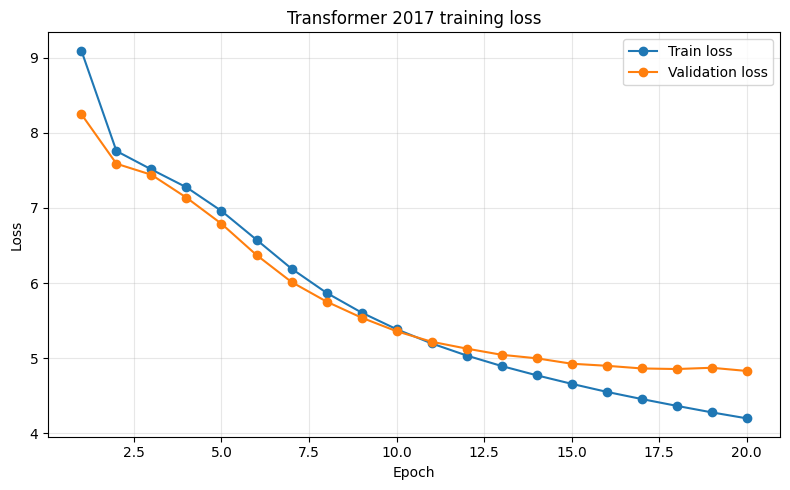

Loss curve saved to: /content/transformer_2017_vi_summarization/outputs/loss_curve.png


,epoch,train_loss,valid_loss,learning_rate,epoch_time_sec
0,1,9.091724,8.246672,0.000030,124.228016
1,2,7.756949,7.588297,0.000059,123.622756
2,3,7.511731,7.441154,0.000089,123.292458
3,4,7.274465,7.136974,0.000118,123.602634
4,5,6.959790,6.789396,0.000148,123.917799
5,6,6.576870,6.373730,0.000177,123.595201
6,7,6.192397,6.014768,0.000207,123.593727
7,8,5.870655,5.754084,0.000236,123.720367
8,9,5.608221,5.540463,0.000266,123.646089
9,10,5.386655,5.359927,0.000295,123.548982


In [18]:
import matplotlib.pyplot as plt

if len(history) == 0:
    raise ValueError('Chưa có history. Hãy chạy cell training trước khi vẽ biểu đồ loss.')

history_df = pd.DataFrame(history)
loss_curve_path = OUTPUT_DIR / 'loss_curve.png'

plt.figure(figsize=(8, 5))
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train loss')
plt.plot(history_df['epoch'], history_df['valid_loss'], marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer 2017 training loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Loss curve saved to: {loss_curve_path}')
display(history_df)


# 15. Sinh thử summary trên tập validation bằng beam search

In [19]:
def normalized_beam_score(log_prob_sum: float, sequence: list[int], length_penalty: float) -> float:
    """Chuẩn hóa điểm beam để tránh ưu tiên câu quá ngắn."""
    effective_length = len([idx for idx in sequence if idx not in {PAD_IDX, BOS_IDX, EOS_IDX}])
    effective_length = max(1, effective_length)
    return log_prob_sum / (effective_length ** length_penalty)


def violates_no_repeat_ngram(sequence: list[int], n: int) -> bool:
    """Kiểm tra n-gram cuối vừa sinh có bị lặp lại trước đó hay không."""
    if n <= 0 or len(sequence) < 2 * n:
        return False

    latest_ngram = tuple(sequence[-n:])
    previous_ngrams = {
        tuple(sequence[i:i + n])
        for i in range(0, len(sequence) - n)
    }
    return latest_ngram in previous_ngrams


@torch.no_grad()
def beam_search_decode(
    model: nn.Module,
    article: str,
    max_len: int = TGT_SEQ_LEN,
    beam_size: int = BEAM_SIZE,
    length_penalty: float = LENGTH_PENALTY,
    no_repeat_ngram_size: int = NO_REPEAT_NGRAM_SIZE,
    min_decode_tokens: int = MIN_DECODE_TOKENS,
) -> str:
    """Sinh summary bằng beam search.

    So với greedy decoding:
    - giữ nhiều ứng viên ở mỗi bước thay vì chỉ chọn token tốt nhất cục bộ;
    - length penalty giúp tránh sinh câu quá ngắn;
    - no-repeat n-gram giảm lỗi lặp cụm từ.
    """
    model.eval()

    src = torch.tensor([encode_source(article, SRC_SEQ_LEN)], dtype=torch.long, device=device)
    src_mask = create_src_mask(src, pad_idx=PAD_IDX)
    encoder_output = model.encode(src, src_mask)

    # Mỗi beam gồm: (sequence_ids, accumulated_log_prob, ended)
    beams = [([BOS_IDX], 0.0, False)]

    for _ in range(max_len - 1):
        candidates = []

        for sequence, score, ended in beams:
            if ended:
                candidates.append((sequence, score, True))
                continue

            ys = torch.tensor([sequence], dtype=torch.long, device=device)
            tgt_mask = create_tgt_mask(ys, pad_idx=PAD_IDX)

            decoder_output = model.decode(encoder_output, src_mask, ys, tgt_mask)
            logits = model.project(decoder_output[:, -1, :])
            log_probs = F.log_softmax(logits, dim=-1).squeeze(0)

            # Không sinh các token đặc biệt không hợp lệ trong phần thân summary.
            log_probs[PAD_IDX] = -float('inf')
            log_probs[BOS_IDX] = -float('inf')
            log_probs[UNK_IDX] = -float('inf')

            # Không cho kết thúc quá sớm.
            generated_token_count = len([idx for idx in sequence if idx not in {PAD_IDX, BOS_IDX, EOS_IDX}])
            if generated_token_count < min_decode_tokens:
                log_probs[EOS_IDX] = -float('inf')

            topk = min(max(beam_size * 2, beam_size), log_probs.size(-1))
            top_log_probs, top_indices = torch.topk(log_probs, k=topk)

            for token_log_prob, token_idx in zip(top_log_probs.tolist(), top_indices.tolist()):
                new_sequence = sequence + [int(token_idx)]

                if violates_no_repeat_ngram(new_sequence, no_repeat_ngram_size):
                    continue

                new_score = score + float(token_log_prob)
                new_ended = int(token_idx) == EOS_IDX
                candidates.append((new_sequence, new_score, new_ended))

        if not candidates:
            break

        candidates.sort(
            key=lambda item: normalized_beam_score(item[1], item[0], length_penalty),
            reverse=True,
        )
        beams = candidates[:beam_size]

        if all(ended for _, _, ended in beams):
            break

    best_sequence, best_score, _ = max(
        beams,
        key=lambda item: normalized_beam_score(item[1], item[0], length_penalty),
    )

    return decode_ids(best_sequence)


@torch.no_grad()
def greedy_decode(model: nn.Module, article: str, max_len: int = TGT_SEQ_LEN) -> str:
    """Giữ lại greedy decoding để so sánh/debug nhanh khi cần."""
    return beam_search_decode(
        model=model,
        article=article,
        max_len=max_len,
        beam_size=1,
        length_penalty=0.0,
        no_repeat_ngram_size=0,
        min_decode_tokens=0,
    )


@torch.no_grad()
def generate_summary(model: nn.Module, article: str, max_len: int = TGT_SEQ_LEN) -> str:
    """Hàm sinh summary mặc định của notebook."""
    if DECODING_STRATEGY == 'beam_search':
        return beam_search_decode(
            model=model,
            article=article,
            max_len=max_len,
            beam_size=BEAM_SIZE,
            length_penalty=LENGTH_PENALTY,
            no_repeat_ngram_size=NO_REPEAT_NGRAM_SIZE,
            min_decode_tokens=MIN_DECODE_TOKENS,
        )

    if DECODING_STRATEGY == 'greedy':
        return greedy_decode(model, article, max_len=max_len)

    raise ValueError(f'DECODING_STRATEGY không hợp lệ: {DECODING_STRATEGY}')


sample_count = min(3, len(valid_df))
for i in range(sample_count):
    sample = valid_df.iloc[i]
    print('=' * 100)
    print('ARTICLE:')
    print(str(sample['article'])[:1000], '...')
    print('\nGOLD SUMMARY:')
    print(sample['summary'])
    print(f'\nMODEL SUMMARY ({DECODING_STRATEGY}):')
    print(generate_summary(model, sample['article']))

ARTICLE:
Giải thưởng công bố gần đây bởi World Travel Awards. Đây là năm thứ hai liên tiếp InterContinental Phu Quoc Long Beach Resort được vinh danh ở hạng mục gia đình trên toàn châu Á. Khu nghỉ dưỡng tọa lạc bên biển Phú Quốc, nổi bật với thiết kế lấy cảm hứng từ đại dương. Khuôn viên rộng rãi với nhiều mảng xanh thiên nhiên đậm chất nhiệt đới. Không gian sảnh lễ tân, phòng nghỉ, villa, nhà hàng... đều được chú trọng để tạo sự hài hòa với biển và cây cối. Du khách có thể chọn nghỉ ngơi tại khu phòng khách sạn rộng rãi, tiện nghi, hoặc những căn hộ, phòng suite, biệt thự cao cấp hướng biển. Mỗi không gian được thiết kế dựa trên tinh thần gắn kết các thành viên trong gia đình. Bên cạnh tiện nghi sang trọng, InterContinental Phu Quoc còn hút khách gia đình nhờ loạt trải nghiệm giải trí, thư giãn đa dạng, phù hợp với mọi độ tuổi. Với trẻ nhỏ, khu Planet Trekker là nơi các bé có thể thoải mái vui chơi, học hỏi từ các đầu sách thiếu nhi, những buổi workshop thủ công... Phụ huynh có thể yê

# 16. Đánh giá ROUGE, BERTScore, BLEU và Too Short Rate trên tập validation

In [20]:
%pip install -q bert-score sacrebleu

In [21]:
import json
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from sacrebleu import corpus_bleu


# ------------------------------------------------------------
# Cấu hình riêng cho các metric đánh giá validation
# ------------------------------------------------------------
# TOO_SHORT_MIN_TOKENS:
#   Nếu prediction có ít hơn số token này, coi là quá ngắn.
#   Ngưỡng 5 phù hợp để bắt các prediction kiểu "", ",,,", "và của".
TOO_SHORT_MIN_TOKENS = 5

# TOO_SHORT_REF_RATIO:
#   Nếu prediction ngắn hơn 50% độ dài reference, coi là quá ngắn.
#   Ví dụ reference dài 20 token nhưng prediction chỉ có 8 token thì bị đánh dấu too short.
TOO_SHORT_REF_RATIO = 0.5


@torch.no_grad()
def generate_predictions(dataframe: pd.DataFrame, max_samples: int | None = None) -> pd.DataFrame:
    """Sinh summary cho tập validation bằng greedy decoding.

    Hàm này chỉ dùng để đánh giá, không gọi backward và không cập nhật trọng số.

    Args:
        dataframe:
            DataFrame validation có 2 cột bắt buộc: article, summary.
        max_samples:
            Số mẫu validation tối đa dùng để đánh giá. Đặt None để dùng toàn bộ val.parquet.

    Returns:
        DataFrame gồm article, reference và prediction.
    """
    eval_df = dataframe.copy().reset_index(drop=True)
    if max_samples is not None:
        eval_df = eval_df.head(max_samples).reset_index(drop=True)
        print(f'[validation metrics] METRIC_MAX_SAMPLES enabled. Using {len(eval_df):,} rows.')

    predictions = []
    references = eval_df['summary'].astype(str).tolist()
    articles = eval_df['article'].astype(str).tolist()

    for idx, article in enumerate(articles, start=1):
        prediction = generate_summary(model, article, max_len=TGT_SEQ_LEN)
        predictions.append(prediction)

        if idx == 1 or idx % 50 == 0 or idx == len(articles):
            print(f'Generated {idx}/{len(articles)} validation summaries')

    return pd.DataFrame({
        'article': articles,
        'reference': references,
        'prediction': predictions,
    })


def compute_rouge_scores(predictions: list[str], references: list[str]) -> dict:
    """Tính ROUGE-1, ROUGE-2 và ROUGE-L trung bình theo F1.

    ROUGE là bộ metric phổ biến nhất trong bài toán summarization.
    use_stemmer=False vì dữ liệu là tiếng Việt, stemmer tiếng Anh không phù hợp.
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    totals = {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        for key in totals:
            totals[key] += scores[key].fmeasure

    n = max(1, len(predictions))
    return {key: value / n for key, value in totals.items()}


def compute_bertscore_scores(predictions: list[str], references: list[str]) -> dict:
    """Tính BERTScore P/R/F1 trung bình bằng mô hình đa ngôn ngữ.

    BERTScore bổ sung góc nhìn ngữ nghĩa cho ROUGE/BLEU vì không chỉ dựa trên trùng token.
    Lần chạy đầu tiên có thể mất thời gian do cần tải checkpoint của BERTSCORE_MODEL_TYPE.
    """
    if len(predictions) == 0:
        return {
            'bertscore_precision': 0.0,
            'bertscore_recall': 0.0,
            'bertscore_f1': 0.0,
        }

    bert_device = 'cuda' if torch.cuda.is_available() else 'cpu'
    precision, recall, f1 = bert_score(
        cands=predictions,
        refs=references,
        model_type=BERTSCORE_MODEL_TYPE,
        device=bert_device,
        batch_size=METRIC_BATCH_SIZE,
        verbose=True,
        rescale_with_baseline=False,
    )

    return {
        'bertscore_precision': float(precision.mean().item()),
        'bertscore_recall': float(recall.mean().item()),
        'bertscore_f1': float(f1.mean().item()),
    }


def compute_bleu_score(predictions: list[str], references: list[str]) -> dict:
    """Tính corpus BLEU bằng sacreBLEU.

    BLEU không phải metric tối ưu nhất cho summarization, nhưng vẫn là độ đo n-gram phổ biến.
    Ta dùng BLEU như metric phụ trong báo cáo, đi kèm ROUGE và BERTScore.
    """
    if len(predictions) == 0:
        return {'bleu': 0.0}

    bleu = corpus_bleu(
        predictions,
        [references],
        tokenize='intl',  # tokenizer quốc tế của sacreBLEU, chạy ổn với văn bản Unicode tiếng Việt.
    )
    return {'bleu': float(bleu.score)}  # sacreBLEU trả điểm theo thang 0-100.


def compute_too_short_rate(predictions: list[str], references: list[str]) -> dict:
    """Tính tỷ lệ summary sinh ra quá ngắn.

    Một prediction được xem là quá ngắn nếu thỏa ít nhất một trong hai điều kiện:
    1. Số token prediction < TOO_SHORT_MIN_TOKENS.
    2. Số token prediction < TOO_SHORT_REF_RATIO * số token reference.

    Metric này rất hữu ích với Transformer train from scratch vì model có thể bị collapse,
    sinh chuỗi quá ngắn hoặc chỉ gồm dấu câu/từ phổ biến.
    """
    if len(predictions) == 0:
        return {
            'avg_prediction_tokens': 0.0,
            'avg_reference_tokens': 0.0,
            'avg_length_ratio_pred_ref': 0.0,
            'empty_prediction_rate': 0.0,
            'too_short_rate': 0.0,
            'too_short_min_tokens': TOO_SHORT_MIN_TOKENS,
            'too_short_ref_ratio': TOO_SHORT_REF_RATIO,
        }

    pred_lengths = [len(metric_tokenize(pred)) for pred in predictions]
    ref_lengths = [len(metric_tokenize(ref)) for ref in references]

    empty_flags = [length == 0 for length in pred_lengths]
    too_short_flags = []
    length_ratios = []

    for pred_len, ref_len in zip(pred_lengths, ref_lengths):
        safe_ref_len = max(1, ref_len)
        length_ratio = pred_len / safe_ref_len
        length_ratios.append(length_ratio)

        is_too_short = (
            pred_len < TOO_SHORT_MIN_TOKENS
            or pred_len < TOO_SHORT_REF_RATIO * safe_ref_len
        )
        too_short_flags.append(is_too_short)

    n = len(predictions)
    return {
        'avg_prediction_tokens': float(sum(pred_lengths) / n),
        'avg_reference_tokens': float(sum(ref_lengths) / n),
        'avg_length_ratio_pred_ref': float(sum(length_ratios) / n),
        'empty_prediction_rate': float(sum(empty_flags) / n),
        'too_short_rate': float(sum(too_short_flags) / n),
        'too_short_min_tokens': TOO_SHORT_MIN_TOKENS,
        'too_short_ref_ratio': TOO_SHORT_REF_RATIO,
    }


# ------------------------------------------------------------
# Load checkpoint tốt nhất trước khi đánh giá validation cuối cùng
# ------------------------------------------------------------
if best_path.exists():
    checkpoint = torch.load(best_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    print(f'Loaded best checkpoint from epoch {checkpoint.get("epoch", "unknown")}: {best_path}')
else:
    print('Best checkpoint chưa tồn tại. Dùng model hiện tại để đánh giá.')
    model.eval()


# ------------------------------------------------------------
# Sinh prediction và tính toàn bộ metric trên val.parquet
# ------------------------------------------------------------
val_predictions_df = generate_predictions(valid_df, max_samples=METRIC_MAX_SAMPLES)

references = val_predictions_df['reference'].astype(str).tolist()
predictions = val_predictions_df['prediction'].astype(str).tolist()

rouge_metrics = compute_rouge_scores(predictions, references)
bertscore_metrics = compute_bertscore_scores(predictions, references)
bleu_metrics = compute_bleu_score(predictions, references)
length_metrics = compute_too_short_rate(predictions, references)

metrics = {
    'num_validation_samples': len(val_predictions_df),
    'decoding': DECODING_STRATEGY,
    'beam_size': BEAM_SIZE if DECODING_STRATEGY == 'beam_search' else 1,
    'length_penalty': LENGTH_PENALTY if DECODING_STRATEGY == 'beam_search' else 0.0,
    'no_repeat_ngram_size': NO_REPEAT_NGRAM_SIZE if DECODING_STRATEGY == 'beam_search' else 0,
    'bert_score_model': BERTSCORE_MODEL_TYPE,
    **rouge_metrics,
    **bertscore_metrics,
    **bleu_metrics,
    **length_metrics,
}

predictions_path = OUTPUT_DIR / 'val_predictions.csv'
metrics_path = OUTPUT_DIR / 'val_metrics.json'

val_predictions_df.to_csv(predictions_path, index=False)
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print('Validation metrics:')
print(json.dumps(metrics, ensure_ascii=False, indent=2))
print(f'Predictions saved to: {predictions_path}')
print(f'Metrics saved to: {metrics_path}')

display(val_predictions_df.head(10)[['reference', 'prediction']])

Loaded best checkpoint from epoch 20: /content/transformer_2017_vi_summarization/outputs/checkpoints/transformer_2017_improved_best.pt
Generated 1/1349 validation summaries
Generated 50/1349 validation summaries
Generated 100/1349 validation summaries
Generated 150/1349 validation summaries
Generated 200/1349 validation summaries
Generated 250/1349 validation summaries
Generated 300/1349 validation summaries
Generated 350/1349 validation summaries
Generated 400/1349 validation summaries
Generated 450/1349 validation summaries
Generated 500/1349 validation summaries
Generated 550/1349 validation summaries
Generated 600/1349 validation summaries
Generated 650/1349 validation summaries
Generated 700/1349 validation summaries
Generated 750/1349 validation summaries
Generated 800/1349 validation summaries
Generated 850/1349 validation summaries
Generated 900/1349 validation summaries
Generated 950/1349 validation summaries
Generated 1000/1349 validation summaries
Generated 1050/1349 validat

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

  0%|          | 0/337 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/169 [00:00<?, ?it/s]

done in 6.34 seconds, 212.81 sentences/sec
Validation metrics:
{
  "num_validation_samples": 1349,
  "decoding": "beam_search",
  "beam_size": 4,
  "length_penalty": 0.8,
  "no_repeat_ngram_size": 3,
  "bert_score_model": "xlm-roberta-base",
  "rouge1": 0.6096463172982114,
  "rouge2": 0.21675520020102226,
  "rougeL": 0.3074677447097037,
  "bertscore_precision": 0.8573024272918701,
  "bertscore_recall": 0.8421778082847595,
  "bertscore_f1": 0.8496243953704834,
  "bleu": 4.392190112902453,
  "avg_prediction_tokens": 99.20756115641215,
  "avg_reference_tokens": 114.69236471460341,
  "avg_length_ratio_pred_ref": 0.901637445904997,
  "empty_prediction_rate": 0.0,
  "too_short_rate": 0.013343217197924388,
  "too_short_min_tokens": 5,
  "too_short_ref_ratio": 0.5
}
Predictions saved to: /content/transformer_2017_vi_summarization/outputs/val_predictions.csv
Metrics saved to: /content/transformer_2017_vi_summarization/outputs/val_metrics.json


,reference,prediction
0,InterContinental Phu Quoc Long Beach Resort đã...,Bài viết giới thiệu các hoạt động văn hóa ẩm t...
1,Việt Nam đã xếp hạng 15 trên bảng xếp hạng 20 ...,Taste Atlas vừa công bố danh sách 100 món ăn n...
2,"Ngày hội Văn hóa, Thể thao và Du lịch các dân ...",Văn bản trên mô tả về sự kiện du lịch quốc gia...
3,"Phú Quốc, đảo ngọc của Việt Nam, đã được vinh ...",Văn bản trên mô tả về sự kiện du lịch quốc gia...
4,KKday Vietnam vừa công bố hợp tác chiến lược v...,Chuỗi sự kiện du lịch Việt Nam được tổ chức tạ...
5,Công ty du lịch Nhật Bản AZ tung ra các tour d...,Du khách có thể tham gia chuyến du lịch mùa hè...
6,"Chùa Phổ Quang, một công trình kiến trúc được ...",Văn bản trên mô tả về sự kiện du lịch ở huyện ...
7,Bài viết giới thiệu hai điểm đến nghỉ dưỡng lý...,Bài viết giới thiệu một số điểm đến du lịch nổ...
8,Tour liên tuyến Hàn Quốc - Nhật Bản (7-8 ngày)...,Bài viết giới thiệu một số điểm đến du lịch nổ...
9,Bảo tàng thịt nướng (Museum of BQQ) sẽ mở cửa ...,Bài viết giới thiệu một số món ăn phổ biến nhấ...


# 18. Đánh giá trên tập test cuối kỳ

Phần này được chuẩn bị sẵn cho ngày thầy cung cấp `test.parquet`.  
Mặc định `RUN_TEST_EVALUATION = False`, nên các cell bên dưới **không làm gì** nếu chưa có tập test.

Khi nhận được tập test:

1. Đặt file vào `DATA_DIR`, ví dụ:

```text
/content/transformer_2017_vi_summarization/data/test.parquet
```

2. Đổi trong cell cấu hình:

```python
RUN_TEST_EVALUATION = True
```

3. Chạy lại phần này. Notebook sẽ:

- load checkpoint tốt nhất `transformer_2017_improved_best.pt`;
- đọc `test.parquet`;
- sinh summary cho từng `article`;
- lưu `test_predictions.csv`;
- nếu test có cột `summary`, tính thêm ROUGE, BERTScore, BLEU và Too Short Rate rồi lưu `test_metrics.json`.

Lưu ý: không dùng test để train, không build vocabulary từ test, không chỉnh tham số dựa trên test. Test chỉ dùng cho đánh giá cuối cùng.


In [22]:
# ================================================================
# Code dự phòng cho tập test cuối kỳ
# ================================================================
# Cell này được viết để an toàn khi chưa có test.parquet:
# - Nếu RUN_TEST_EVALUATION = False: chỉ in hướng dẫn và bỏ qua.
# - Nếu RUN_TEST_EVALUATION = True: đọc test.parquet, sinh prediction,
#   và tính metric nếu test có cột summary.


def test_file_exists() -> bool:
    """Kiểm tra test.parquet có tồn tại trong các thư mục mà notebook hỗ trợ hay chưa."""
    try:
        _ = find_data_path(TEST_FILENAME)
        return True
    except FileNotFoundError:
        return False


def clean_test_dataframe(dataframe: pd.DataFrame, name: str = 'test') -> tuple[pd.DataFrame, bool]:
    """Làm sạch tập test.

    Tập test cuối kỳ có thể có 2 dạng:
    1. Có article và summary: dùng để sinh prediction + tính metric.
    2. Chỉ có article: dùng để sinh prediction nộp/chấm ngoài.

    Hàm trả về:
    - dataframe đã làm sạch;
    - has_reference = True nếu có cột summary hợp lệ.
    """
    if TEST_ARTICLE_COL not in dataframe.columns:
        raise ValueError(
            f'[{name}] Dataset thiếu cột {TEST_ARTICLE_COL!r}. '
            f'Các cột hiện có: {list(dataframe.columns)}'
        )

    has_reference = TEST_SUMMARY_COL in dataframe.columns

    keep_cols = [TEST_ARTICLE_COL]
    if has_reference:
        keep_cols.append(TEST_SUMMARY_COL)

    dataframe = dataframe[keep_cols].copy()
    dataframe = dataframe.dropna(subset=[TEST_ARTICLE_COL])
    dataframe = dataframe[dataframe[TEST_ARTICLE_COL].astype(str).str.strip().ne('')]

    if has_reference:
        dataframe = dataframe.dropna(subset=[TEST_SUMMARY_COL])
        dataframe = dataframe[dataframe[TEST_SUMMARY_COL].astype(str).str.strip().ne('')]

    dataframe = dataframe.drop_duplicates().reset_index(drop=True)

    print(f'[{name}] Rows after cleaning: {len(dataframe):,}')
    print(f'[{name}] Has reference summary:', has_reference)
    return dataframe, has_reference


@torch.no_grad()
def generate_test_predictions(dataframe: pd.DataFrame, max_samples: int | None = None) -> pd.DataFrame:
    """Sinh summary cho tập test bằng mô hình Transformer 2017 đã train.

    Hàm này chỉ dùng để inference/evaluation, không gọi backward, không cập nhật trọng số.
    """
    eval_df = dataframe.copy().reset_index(drop=True)
    if max_samples is not None:
        eval_df = eval_df.head(max_samples).reset_index(drop=True)
        print(f'[test] TEST_MAX_SAMPLES enabled. Using {len(eval_df):,} rows.')

    articles = eval_df[TEST_ARTICLE_COL].astype(str).tolist()
    predictions = []

    for idx, article in enumerate(articles, start=1):
        pred = generate_summary(model, article, max_len=TGT_SEQ_LEN)
        predictions.append(pred)

        if idx == 1 or idx % 50 == 0 or idx == len(articles):
            print(f'Generated {idx}/{len(articles)} test summaries')

    result_df = pd.DataFrame({
        TEST_ARTICLE_COL: articles,
        'prediction': predictions,
    })

    if TEST_SUMMARY_COL in eval_df.columns:
        result_df['reference'] = eval_df[TEST_SUMMARY_COL].astype(str).tolist()

    return result_df


In [23]:
# ================================================================
# Chạy đánh giá test khi đã có test.parquet
# ================================================================
# Để kích hoạt phần này:
# 1. Upload test.parquet vào DATA_DIR.
# 2. Đổi RUN_TEST_EVALUATION = True ở cell cấu hình.
# 3. Chạy cell này.

if not RUN_TEST_EVALUATION:
    print('RUN_TEST_EVALUATION = False, bỏ qua phần test.')
    print('Khi nhận được test.parquet, hãy đặt file vào DATA_DIR và đổi RUN_TEST_EVALUATION = True.')
else:
    if not test_file_exists():
        raise FileNotFoundError(
            f'RUN_TEST_EVALUATION = True nhưng chưa tìm thấy {TEST_FILENAME}. '
            f'Hãy đặt file vào {DATA_DIR} hoặc /content/data.'
        )

    # Luôn load checkpoint tốt nhất trước khi đánh giá test.
    # Như vậy kết quả test dùng model có validation loss tốt nhất, không phải epoch cuối.
    if best_path.exists():
        checkpoint = torch.load(best_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)
        model.eval()
        print(f'Loaded best checkpoint from epoch {checkpoint.get("epoch", "unknown")}: {best_path}')
    else:
        print('Cảnh báo: chưa tìm thấy best checkpoint. Dùng model hiện tại trong RAM để sinh test predictions.')
        model.eval()

    raw_test_df = read_parquet_safely(TEST_FILENAME, name='test')
    test_df, test_has_reference = clean_test_dataframe(raw_test_df, name='test')

    test_predictions_df = generate_test_predictions(test_df, max_samples=TEST_MAX_SAMPLES)

    test_predictions_path = OUTPUT_DIR / 'test_predictions.csv'
    test_predictions_df.to_csv(test_predictions_path, index=False)
    print(f'Test predictions saved to: {test_predictions_path}')

    # Nếu test.parquet có summary thì tính metric giống validation.
    if test_has_reference:
        test_references = test_predictions_df['reference'].astype(str).tolist()
        test_predictions = test_predictions_df['prediction'].astype(str).tolist()

        test_rouge_metrics = compute_rouge_scores(test_predictions, test_references)
        test_bertscore_metrics = compute_bertscore_scores(test_predictions, test_references)
        test_bleu_metrics = compute_bleu_score(test_predictions, test_references)
        test_length_metrics = compute_too_short_rate(test_predictions, test_references)

        test_metrics = {
            'num_test_samples': len(test_predictions_df),
            'decoding': DECODING_STRATEGY,
            'beam_size': BEAM_SIZE if DECODING_STRATEGY == 'beam_search' else 1,
            'length_penalty': LENGTH_PENALTY if DECODING_STRATEGY == 'beam_search' else 0.0,
            'no_repeat_ngram_size': NO_REPEAT_NGRAM_SIZE if DECODING_STRATEGY == 'beam_search' else 0,
            'bert_score_model': BERTSCORE_MODEL_TYPE,
            **test_rouge_metrics,
            **test_bertscore_metrics,
            **test_bleu_metrics,
            **test_length_metrics,
        }

        test_metrics_path = OUTPUT_DIR / 'test_metrics.json'
        with open(test_metrics_path, 'w', encoding='utf-8') as f:
            json.dump(test_metrics, f, ensure_ascii=False, indent=2)

        print('Test metrics:')
        print(json.dumps(test_metrics, ensure_ascii=False, indent=2))
        print(f'Test metrics saved to: {test_metrics_path}')

        display(test_predictions_df[[TEST_ARTICLE_COL, 'reference', 'prediction']].head(10))
    else:
        print('test.parquet không có cột summary nên không tính ROUGE/BERTScore.')
        print('Chỉ lưu prediction để nộp hoặc chấm bằng hệ thống ngoài.')
        display(test_predictions_df[[TEST_ARTICLE_COL, 'prediction']].head(10))


RUN_TEST_EVALUATION = False, bỏ qua phần test.
Khi nhận được test.parquet, hãy đặt file vào DATA_DIR và đổi RUN_TEST_EVALUATION = True.


# 19. Gợi ý thao tác khi nhận tập test

Khi thầy cung cấp `test.parquet`, không sửa lại kiến trúc hoặc training loop. Chỉ làm đúng các bước sau:

1. Upload `test.parquet` vào thư mục `data/`.
2. Kiểm tra tên file đúng là `test.parquet`; nếu tên khác, sửa `TEST_FILENAME` trong cell cấu hình.
3. Đổi `RUN_TEST_EVALUATION = True`.
4. Nếu runtime vẫn còn model/checkpoint sau training, chạy từ phần **18. Đánh giá trên tập test cuối kỳ** trở xuống.
5. Nếu runtime đã mất, chạy lại notebook từ đầu để khôi phục environment và load checkpoint.
6. Lấy file `outputs/test_predictions.csv` để nộp hoặc đưa vào báo cáo.
7. Nếu có `outputs/test_metrics.json`, dùng các chỉ số ROUGE/BERTScore/BLEU/Too Short Rate trong báo cáo cuối.

Không nên train lại trên test, không build vocabulary từ test, và không chọn checkpoint dựa trên test. Test chỉ dùng một lần để đánh giá cuối cùng.


# 20. Gợi ý mô tả kết quả trong báo cáo

Khi viết báo cáo, có thể mô tả notebook như sau:

- Mô hình Transformer encoder-decoder được tự cài đặt bằng PyTorch, không dùng `nn.Transformer`.
- Kiến trúc bám sát Transformer 2017: sinusoidal positional encoding, multi-head attention chuẩn, feed-forward ReLU, post-norm Add & Norm, dropout và Xavier initialization.
- Dữ liệu `article → summary` được đưa vào encoder-decoder theo đúng bài toán sequence-to-sequence.
- Decoder nhận `summary` đã dịch phải bằng token `<bos>` và học dự đoán token tiếp theo.
- Loss được tính bằng CrossEntropyLoss, bỏ qua padding và dùng label smoothing `0.1` như paper.
- Optimizer dùng Adam với `β1 = 0.9`, `β2 = 0.98`, `eps = 1e-9` và learning-rate schedule có warmup theo Transformer 2017.
- Validation được đọc từ file `val.parquet` riêng, không chia từ tập train.
- Biểu đồ loss được vẽ để quan sát quá trình học qua từng epoch.
- Sau training, mô hình được đánh giá trên tập validation bằng ROUGE-1, ROUGE-2, ROUGE-L, BERTScore, BLEU và Too Short Rate.
- Bản cải tiến dùng SentencePiece BPE, dynamic padding + length-bucketed batches và beam search decoding có length penalty/no-repeat n-gram để tối ưu hơn cho dataset tiếng Việt.

Nếu kết quả tóm tắt chưa tốt, cần nhấn mạnh rằng mô hình được train từ đầu trên dataset nhỏ nên chủ yếu dùng để minh họa kiến trúc và pipeline huấn luyện, không thể so sánh trực tiếp với các mô hình pretrained như ViT5/BARTPho.
